In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


--- Phase 1: SDF 그리드 생성 ---
Grid Shape: (64, 64, 64)
Min Value: -0.198, Max Value: 0.932

--- Phase 2: 시각화 및 저장 ---


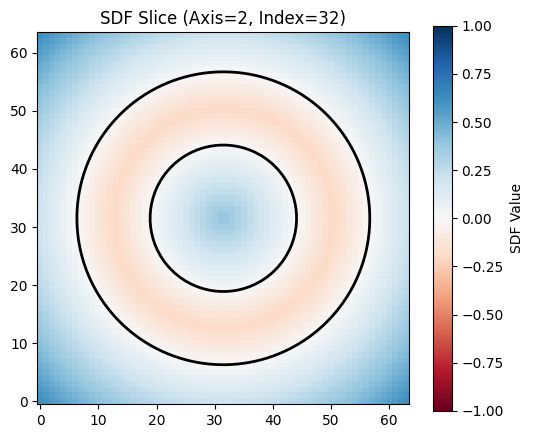

In [ ]:
# 모듈 임포트
# (만약 에러나면 VS Code를 껐다 켜거나 커널 재시작 필요)
from modules.sdf_generator import create_sample_shape, to_grid
from modules.visualizer import plot_slice, save_mesh_as_obj, visualize_npy_sdf
import numpy as np

# 1. 도형 생성 (Phase 1)
print("--- Phase 1: SDF 그리드 생성 ---")
my_shape = create_sample_shape()

# my shape -> sdf 해상도 64로 설정
resolution = 64
sdf_grid = to_grid(my_shape, resolution=resolution, domain_size=2.0)


# 입자 샘플링을 위해 Numpy 포맷으로 저장
np.save("sdf_grid_64.npy", sdf_grid)

print(f"Grid Shape: {sdf_grid.shape}")
print(f"Min Value: {sdf_grid.min():.3f}, Max Value: {sdf_grid.max():.3f}")


In [ ]:

# 2. 데이터 시각화 (Phase 2)
print("\n--- Phase 2: 시각화 및 저장 ---")

# (1) 2D 단면 확인 (내부가 파란색인지 확인하세요)
plot_slice(sdf_grid, axis=2) # Z축 기준 중앙 단면

# (2) 3D OBJ 파일 저장
# save_mesh_as_obj(sdf_grid, filename="test_shape_64.obj")


📂 파일 로드 성공! 데이터 크기: (64, 64, 64)


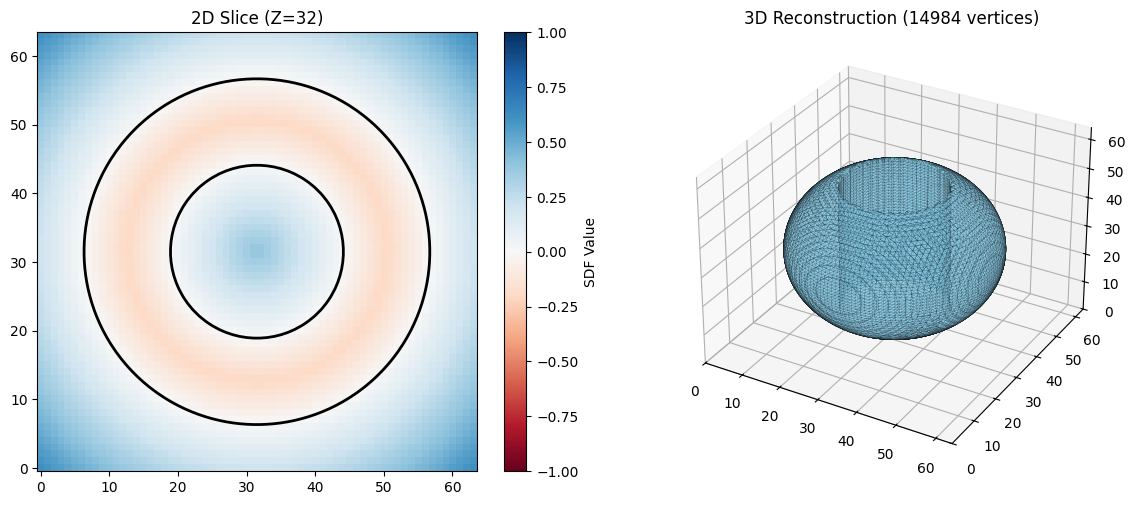

In [8]:
visualize_npy_sdf("sdf_grid_64.npy")

샘플링된 파티클 수: 593


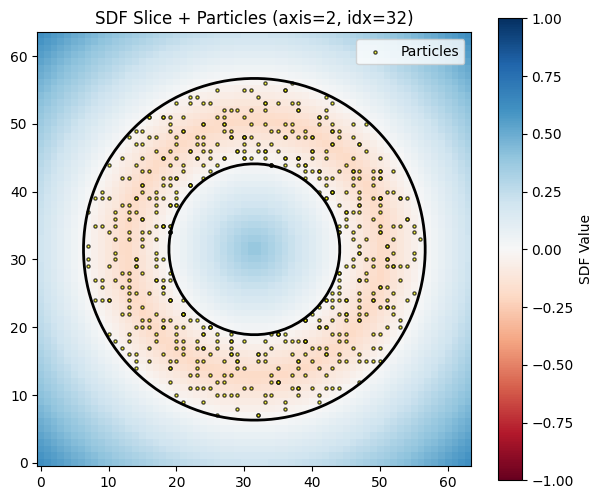

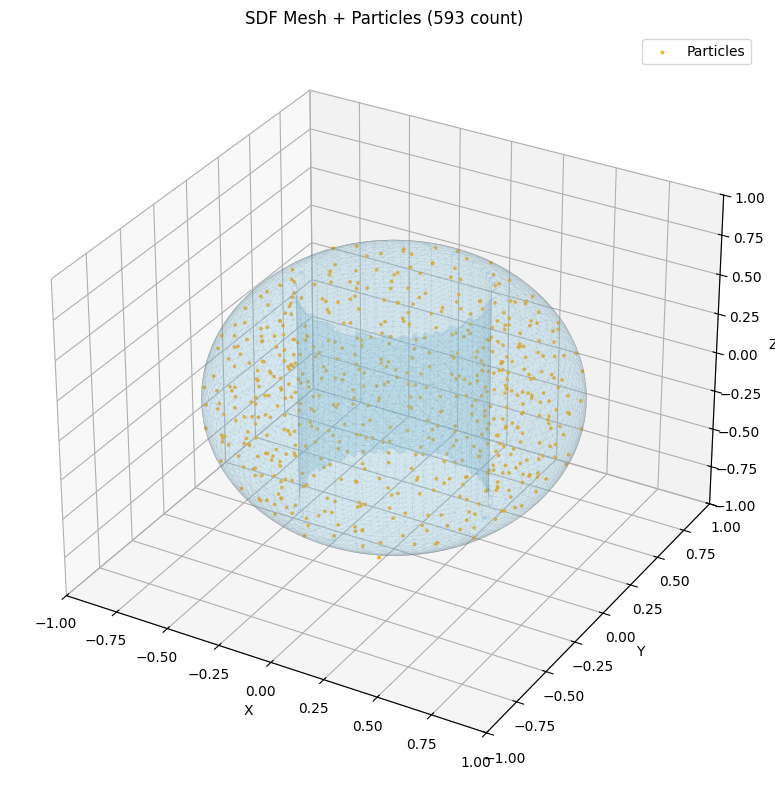

In [ ]:
from modules.particle_sampler import sample_particles_poisson, sample_particles_jittered, sample_particles_dart_throwing
from modules.visualizer import plot_particles_and_sdf_slice, plot_particles_and_mesh

# SDF 그리드 불러오기
sdf_grid = np.load("sdf_grid_64.npy")

# dart throwing 방식 샘플링
particles = sample_particles_dart_throwing(sdf_grid, spacing = 0.1, max_trials=2000)
print(f"샘플링된 파티클 수: {len(particles)}")

plot_particles_and_sdf_slice(sdf_grid, particles)
plot_particles_and_mesh(
    sdf_grid=sdf_grid, 
    particles=particles, 
    domain_size=2.0
)

샘플링된 파티클 수: 43616


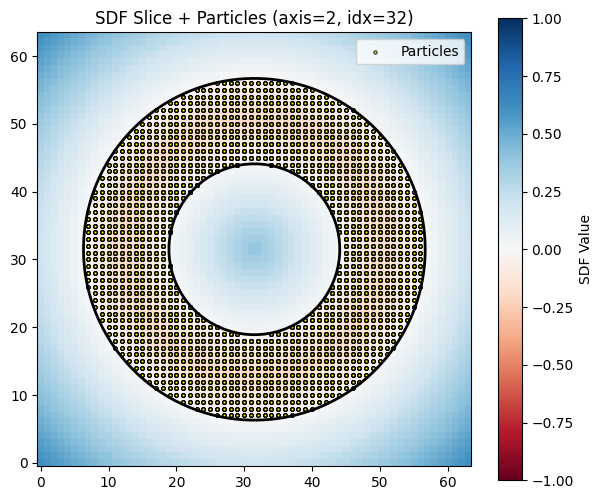

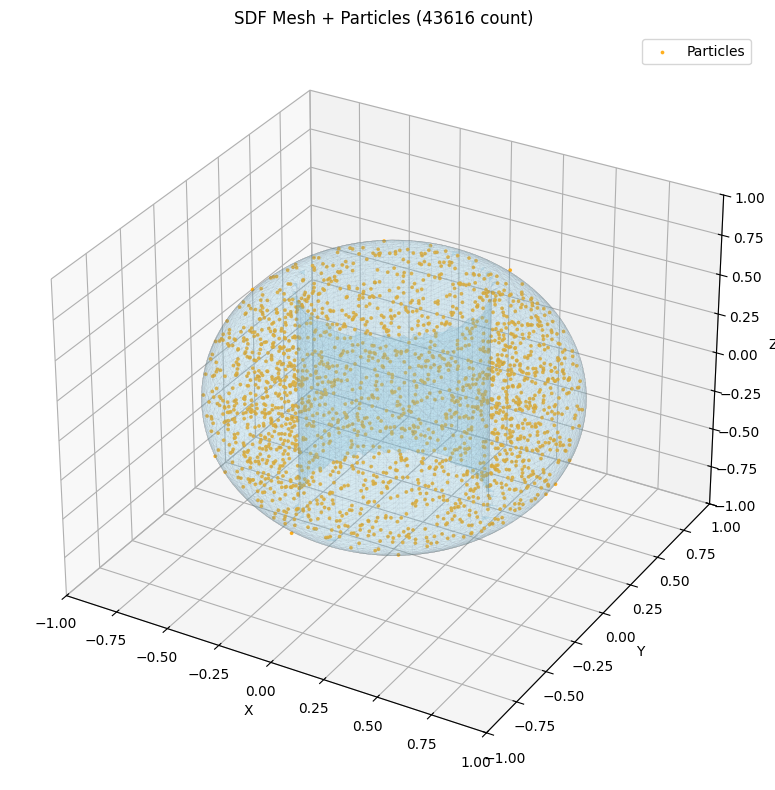

In [ ]:
from modules.particle_sampler import sample_particles_poisson, sample_particles_jittered, sample_particles_dart_throwing
from modules.visualizer import plot_particles_and_sdf_slice, plot_particles_and_mesh

# SDF 그리드 불러오기
sdf_grid = np.load("sdf_grid_64.npy")

# jittered 방식 샘플링
particles = sample_particles_jittered(sdf_grid, domain_size=2.0, jitter_scale=0.8)
print(f"샘플링된 파티클 수: {len(particles)}")

plot_particles_and_sdf_slice(sdf_grid, particles)
plot_particles_and_mesh(
    sdf_grid=sdf_grid, 
    particles=particles, 
    domain_size=2.0
)

   -> 목표 파티클: 2000개 / 추정 최소 거리(r): 0.0794
샘플링된 파티클 수: 193


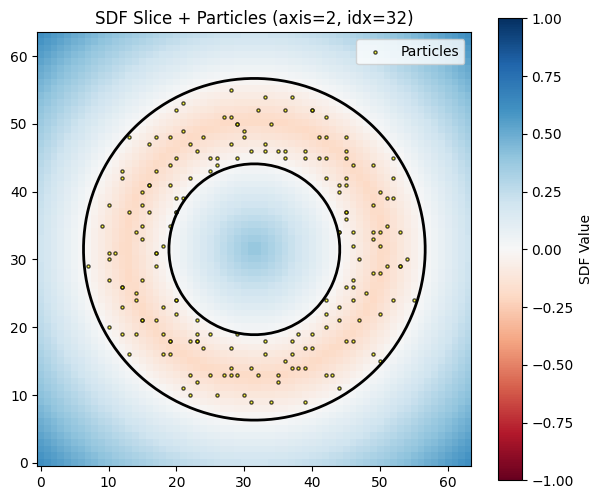

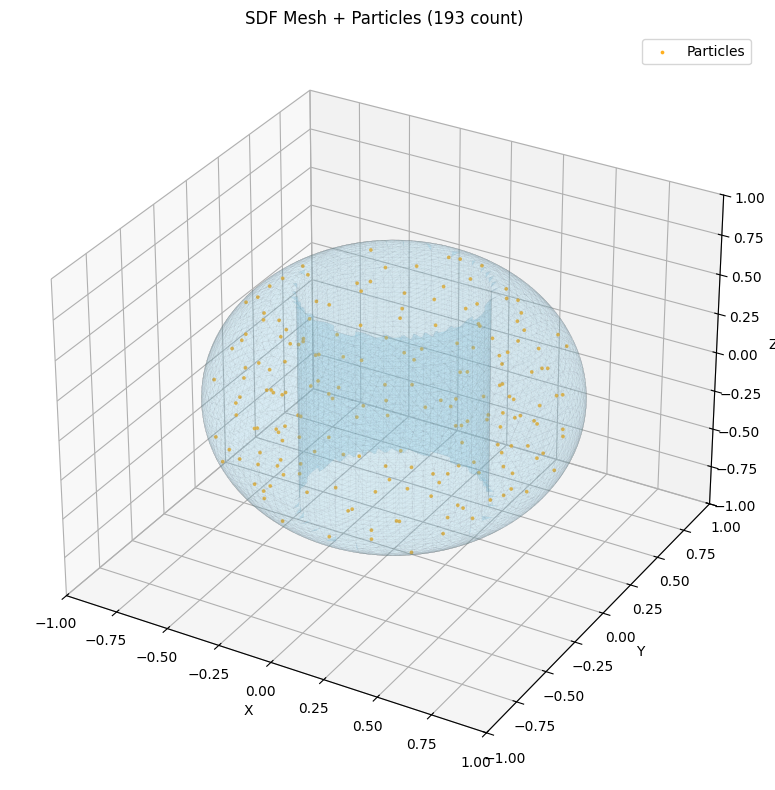

In [17]:
from modules.particle_sampler import sample_particles_poisson, sample_particles_jittered, sample_particles_dart_throwing
from modules.visualizer import plot_particles_and_sdf_slice, plot_particles_and_mesh

# SDF 그리드 불러오기
sdf_grid = np.load("sdf_grid_64.npy")

# Poisson Disk 방식 샘플링
particles = sample_particles_poisson(sdf_grid, domain_size=2.0, num_particles=2000)
print(f"샘플링된 파티클 수: {len(particles)}")

plot_particles_and_sdf_slice(sdf_grid, particles)
plot_particles_and_mesh(
    sdf_grid=sdf_grid, 
    particles=particles, 
    domain_size=2.0
)